In [32]:
import json
import gzip
import matplotlib.pyplot as plt
from matplotlib import lines, colormaps
import matplotlib as mpl
import numpy as np
import os
import sys
import glob
from pathlib import Path

# helper_dir = Path('/eos/user/l/lpauwels/Simulations/MomentumAcceptance/HelperFunctions/')
helper_dir = Path('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/')
sys.path.insert(0, str(helper_dir))

import midpoints_analysis as mpa
import plot_helpers as ph
import intensity_loss as il
from combine_death_turns import load_death_turns
import acceptance_centers as ac

In [2]:
def load_data(line_types, chromas, planes, result_path=None, verbose=True):
    if result_path is None:
        result_path = study_path.parents[2] / 'results'
    result_path = Path(result_path).resolve()

    data = {}
    for lt in line_types:
        data[lt] = {}
        for chroma in chromas:
            data[lt][chroma] = {}
            for plane in planes:
                data[lt][chroma][plane] = {}
                file_path = result_path / f'death_turns_{lt}_{chroma}_{plane}.json.gz'
                if not file_path.exists():
                    if verbose:
                        print(f'File {file_path} does not exist, skipping')
                    continue
                if verbose:
                    print(f'Loading data from {file_path}')
                with gzip.open(file_path, 'rt', encoding='utf-8') as f:
                    death_turns_data = json.load(f)
                turns, counts = np.unique(death_turns_data['at_turn'], return_counts=True)
                data[lt][chroma][plane] = {'turns' : turns, 'counts' : counts}
    return data

def df_to_delta(df):
    slip_factor = 0.0017935055033301713
    f = 200_000_000
    return 1/slip_factor * df/f

def get_normalised_intensity_loss(data, line_types, chromas, planes, total_particles, sweep_per_turn=1.0):
    normalised_intensity_loss = {}
    for lt in line_types:
        normalised_intensity_loss[lt] = {}
        for chroma in chromas:
            normalised_intensity_loss[lt][chroma] = {}
            for plane in planes:
                turns, counts = np.unique(data[lt][chroma][plane]['at_turn'], return_counts=True)

                turns = np.concatenate(([0], turns))
                counts = np.concatenate(([0], counts))

                deltas = df_to_delta(turns * sweep_per_turn)
                if plane == 'DPneg':
                    deltas = -deltas
                
                normalised_intensity_loss[lt][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / total_particles}
    return normalised_intensity_loss


# Loading data

In [3]:
# results_path = Path('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles')
results_path = Path('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles')
paths = list(results_path.iterdir())

In [5]:
paths

[PosixPath('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/resonance_margin_scan'),
 PosixPath('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/qpy_zero'),
 PosixPath('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/tune_mirror'),
 PosixPath('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/qpx_zero')]

In [8]:
data = {'qpx_zero' : load_death_turns(Path(('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/qpx_zero')), 'chroma_scan_qpx', 'qpx_zero'),
        'qpy_zero' : load_death_turns(Path(('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/qpy_zero')), 'chroma_scan_qpy', 'qpy_zero'),
        'resonance_margin_scan' : load_death_turns(Path(('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/resonance_margin_scan')), 'tune_scan', 'resonance_margin_scan'), 
        'tune_mirror_scan' : load_death_turns(Path(('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/tune_mirror')), 'tune_scan', 'tune_mirror')}

Loading 62 files from /Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/TuneDiagramVariations/results/JsonFiles/qpx_zero
  -0.1                            DPneg
  -0.1                            DPpos
  -0.2                            DPneg
  -0.2                            DPpos
  -0.3                            DPneg
  -0.3                            DPpos
  -0.4                            DPneg
  -0.4                            DPpos
  -0.5                            DPneg
  -0.5                            DPpos
  -0.6                            DPneg
  -0.6                            DPpos
  -0.7                            DPneg
  -0.7                            DPpos
  -0.8                            DPneg
  -0.8                            DPpos
  -0.9                            DPneg
  -0.9                            DPpos
  -1.0                            DPneg
  -1.0                            DPpos
  -1.1                            DPneg
  -1.1                     

In [9]:
# path_study_results = Path("/eos/user/l/lpauwels/Simulations/MomentumAcceptance/IntensityScan2/study_results")
path_study_results = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/IntensityScan2/study_results")
name_files = [p.name for p in path_study_results.iterdir()]

sweep_per_turn = 1.0
data['linear'] = {}
data['errors'] = {}
for name_file in name_files:
    with gzip.open(path_study_results / name_file, "rt") as f:
        study_results = json.load(f)

    line_type = name_file.split("_")[1]
    chroma = float(name_file.split("_")[2].split(".json")[0])
    print(line_type, chroma)
    if chroma not in data[line_type]:
        data[line_type][chroma] = {}
    
    for plane in list(study_results.keys()):
        assert abs(study_results[plane]['sweep_per_turn']) == sweep_per_turn
        turns, counts = np.unique(study_results[plane]['at_turn'], return_counts=True)
        data[line_type][chroma][plane] = {'turns' : turns, 'counts' : counts}

errors 0.1
linear -0.2
errors -0.1
linear 0.3
errors -1.5
errors 1.5
linear 1.1
errors -0.7
linear 0.8
errors 0.7
linear -0.4
errors 1.3
linear -1.0
linear 0.5
linear -0.9
errors -1.3
linear -0.3
errors 0.0
errors -1.4
linear 0.2
errors 1.4
errors -0.6
linear 1.0
linear -0.5
linear 0.9
errors 0.6
linear -1.1
errors 1.2
errors -1.2
linear -0.8
linear 0.4
linear 1.5
errors -0.3
errors 0.3
linear -1.4
linear 0.1
errors 0.5
linear -0.6
linear 1.3
errors -0.5
linear 0.7
errors 0.8
errors -1.1
errors 1.1
errors -0.8
linear -1.2
errors -0.2
linear 1.4
linear -0.1
errors 0.2
linear -1.5
linear 0.0
linear -0.7
errors 0.4
errors -0.4
linear 1.2
errors -1.0
linear 0.6
errors 0.9
linear -1.3
errors -0.9
errors 1.0


# Intensity loss

In [10]:
xi = np.round(np.linspace(-1.5, 1.5, 31), 1)

In [11]:
data.keys()

dict_keys(['qpx_zero', 'qpy_zero', 'resonance_margin_scan', 'tune_mirror_scan', 'linear', 'errors'])

In [12]:
intensity_loss = get_normalised_intensity_loss(data, ['qpx_zero', 'qpy_zero', 'resonance_margin_scan', 'tune_mirror_scan'], xi, ['DPneg', 'DPpos'], total_particles=1_000_000) 

In [13]:
num_particles = 1_000_000
for line_type in ['linear', 'errors']:
    intensity_loss[line_type] = {}
    for chroma in sorted(data[line_type].keys()):
        intensity_loss[line_type][chroma] = {}
        for plane in ['DPpos', 'DPneg']:
            turns = data[line_type][chroma][plane]['turns']
            counts = data[line_type][chroma][plane]['counts']

            turns = np.concatenate(([0], turns))
            counts = np.concatenate(([0], counts))

            deltas = df_to_delta(turns * sweep_per_turn)
            if plane == 'DPneg':
                deltas = -deltas
            
            intensity_loss[line_type][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / num_particles}

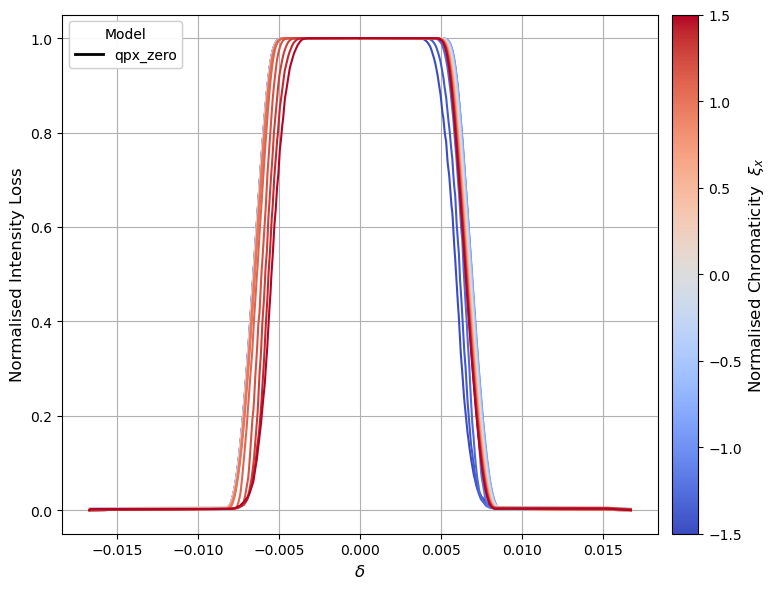

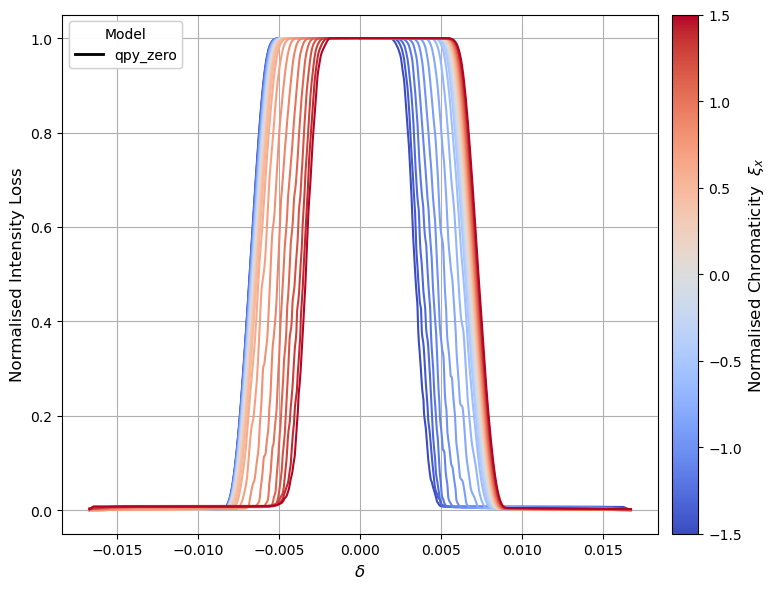

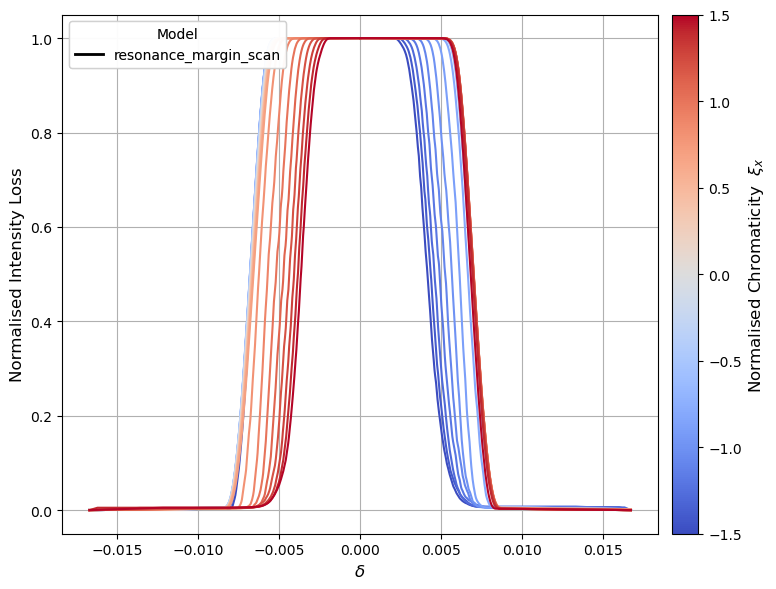

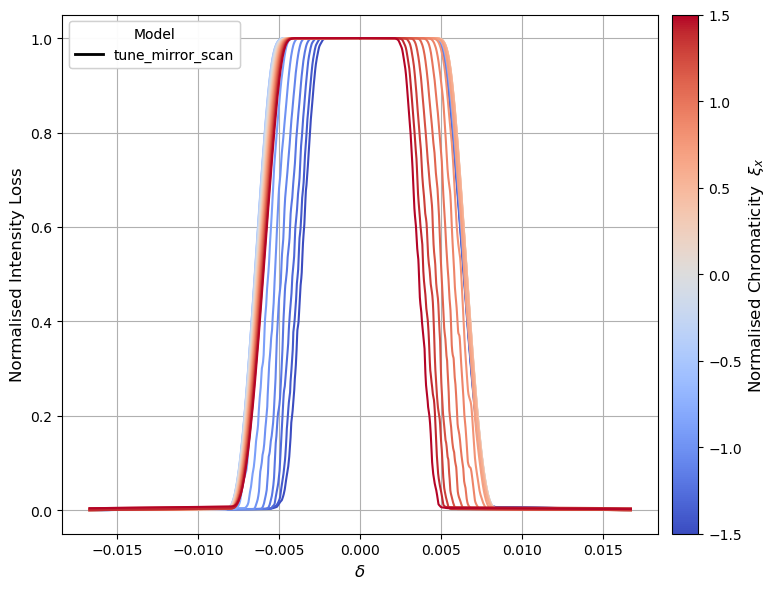

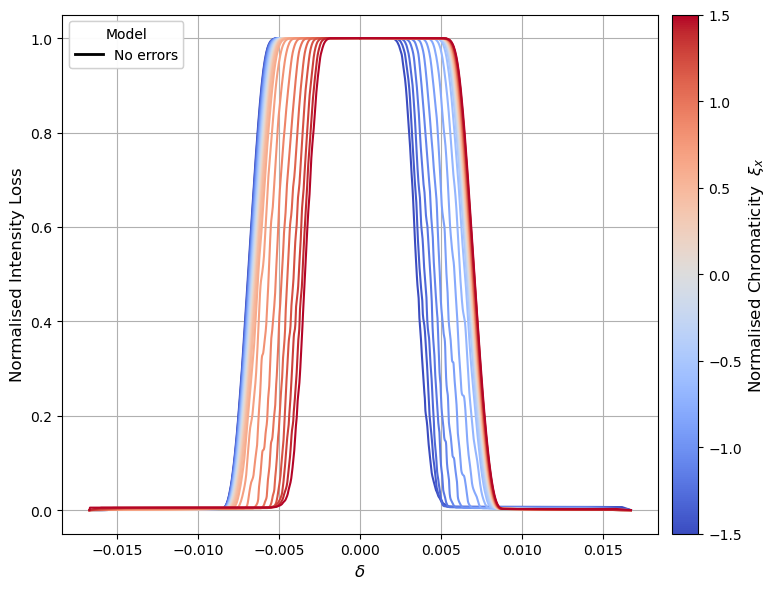

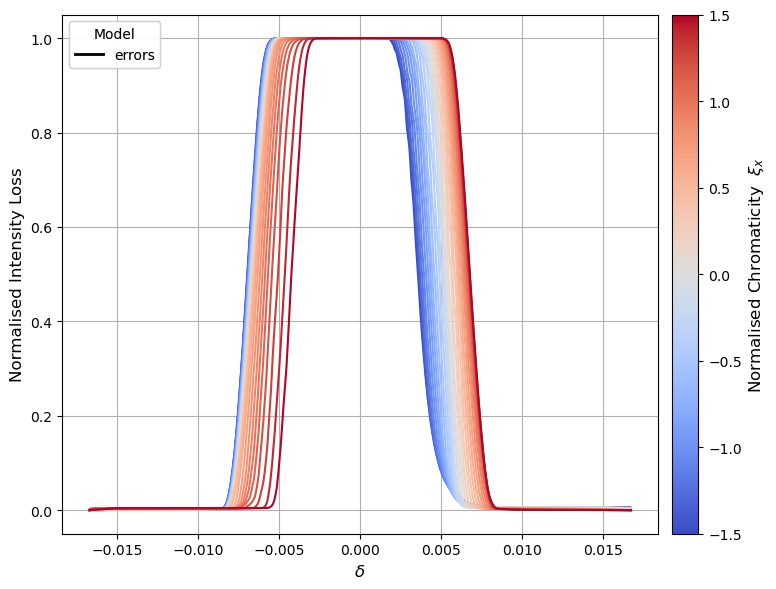

In [14]:
for lt in intensity_loss.keys():
    il.plot_intensity_drop(normalised_intensity=intensity_loss, line_types=[lt], savefig=f'IntensityLoss/{lt}.png')

Need to update plotting function because now it is not just xi_x all the time...

# Midpoints

Will probably need a better way of representing chroma evolution, again we are not always changing the same chroma anymore...

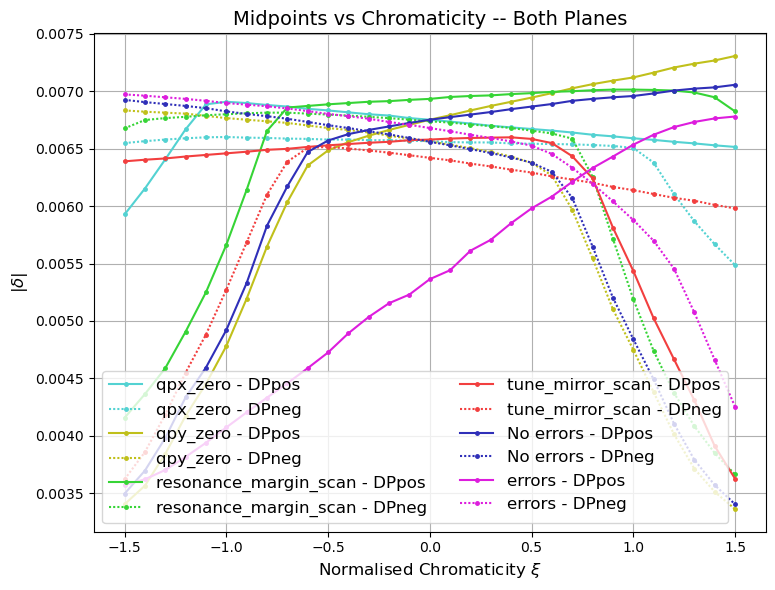

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel='Normalised Chromaticity $\\xi$', ylabel='$|\\delta|$'>)

In [40]:
midpoints = mpa.get_midpoints(intensity_loss)
mpa.plot_midpoints(midpoints, planes = ['DPpos', 'DPneg'], savefig='midpoints_all.pdf')

# Centres and Acceptance

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Normalised Chromaticity $\\xi_x$', ylabel='Centre $C = \\frac{\\delta_+ + \\delta_-}{2}$'>)

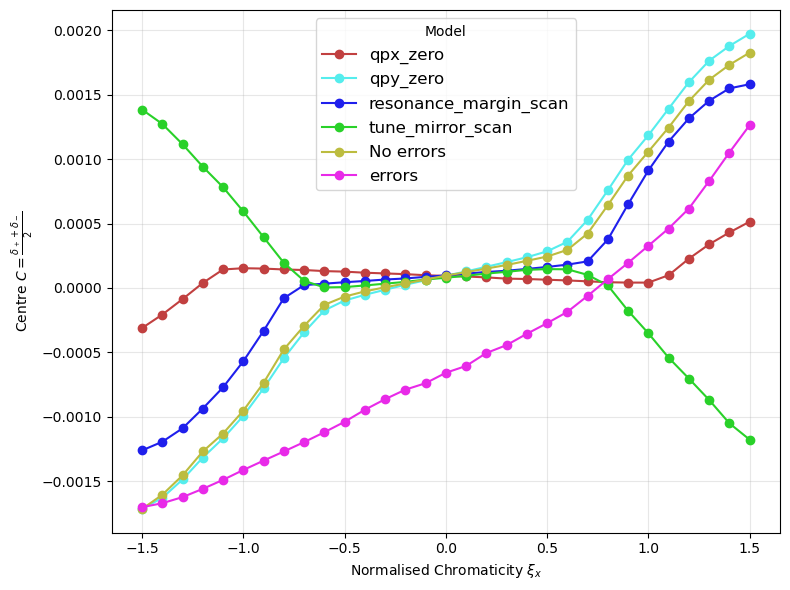

In [38]:
ac.plot_centers(midpoints, savefig='centres_all.pdf')

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Normalised Chromaticity $\\xi_x$', ylabel='Acceptance $A = \\delta_+ - \\delta_-$'>)

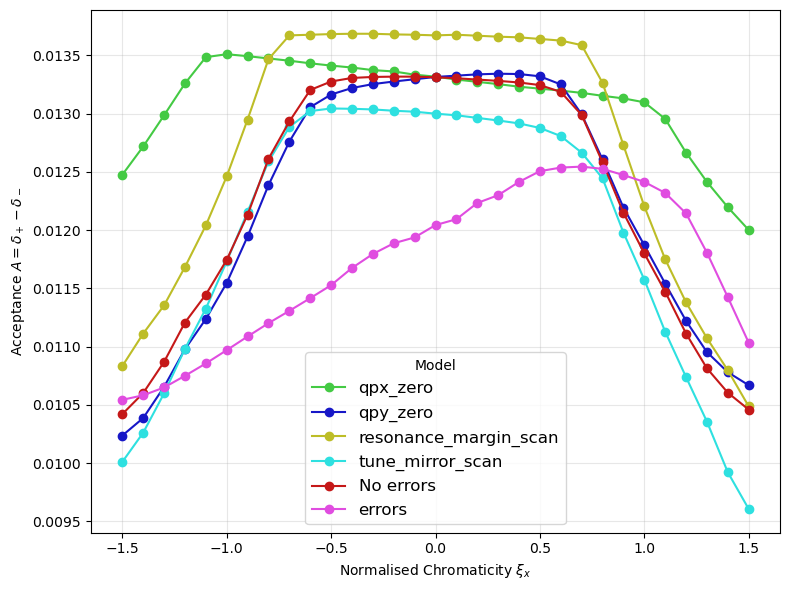

In [66]:
ac.plot_acceptance(midpoints, savefig='acceptance_all.pdf')

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Normalised Chromaticity $\\xi_x$', ylabel='Acceptance $A = \\delta_+ - \\delta_-$'>)

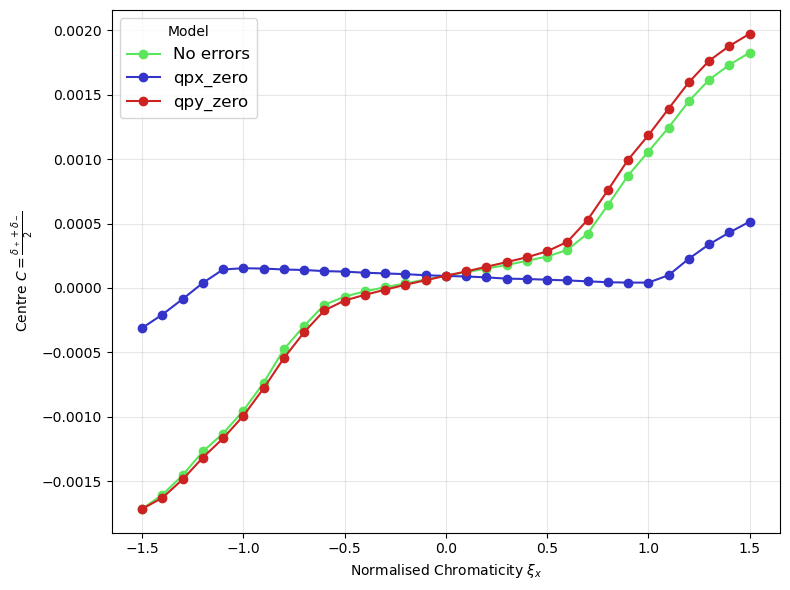

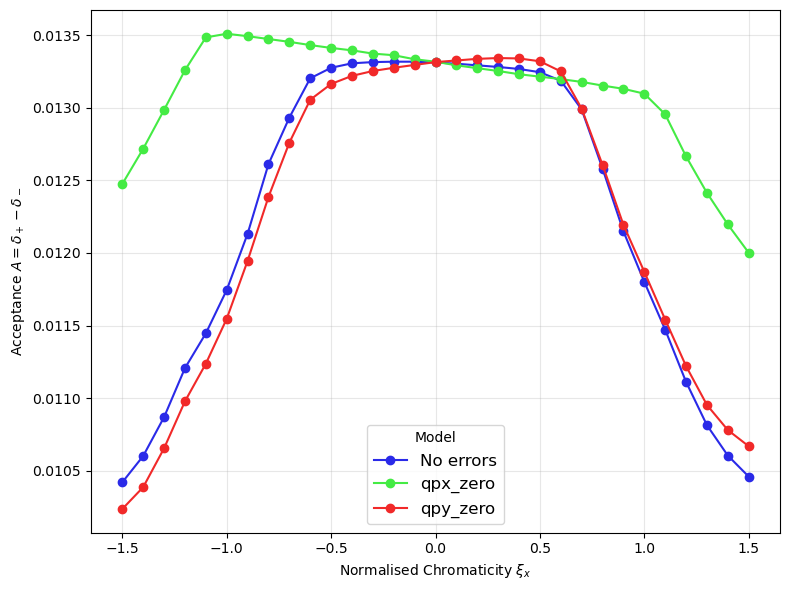

In [68]:
ac.plot_centers(midpoints, line_types=['linear', 'qpx_zero', 'qpy_zero'], savefig='centres_qp_zeros.pdf')
ac.plot_acceptance(midpoints, line_types=['linear', 'qpx_zero', 'qpy_zero'], savefig='acceptance_qp_zeros.pdf')

# Tune diagrams

In [19]:
import xtrack as xt
from tune_diagram import TuneDiagram, SweepTrajectory

In [69]:
line = xt.load('/Users/lisepauwels/sps_simulations/injection_lines/sps_q20_inj.json')
env = line.env

error_variants = {
    'dipole_b3' : [0, 0, 1, 0, 0, 0],
    'dipole_b5' : [0, 0, 0, 0, 1, 0],
    'dipole_b3b5': [0, 0, 1, 0, 1, 0],
    'quadrupole_b4': [0, 0, 0, 1, 0, 0],
    'quadrupole_b6': [0, 0, 0, 0, 0, 1],
    'quadrupole_b4b6': [0, 0, 0, 1, 0, 1],
    'dipole_b3_quadrupole_b4': [0, 0, 1, 1, 0, 0],
    'all': [0, 0, 1, 1, 1, 1]
}
error_variant_name = 'all'

cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

tw = line.twiss()
# remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2)

# Installing errors
b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
tte = env.elements.get_table()
mask_rbends = tte.element_type == 'RBend'
mask_quads = tte.element_type == 'Quadrupole'
mask_sextupoles = tte.element_type == 'Sextupole'

mba = tte.rows[mask_rbends].rows['mba.*'].name
mbb = tte.rows[mask_rbends].rows['mbb.*'].name
qf = tte.rows[mask_quads].rows['qf.*'].name
qd = tte.rows[mask_quads].rows['qd.*'].name
lsf = tte.rows[mask_sextupoles].rows['lsf.*'].name
lsd = tte.rows[mask_sextupoles].rows['lsd.*'].name

env.vars['qph_setvalue'] = 0.0
env.vars['qpv_setvalue'] = 0.0

# Set the strengths according to Hannes' measurements
for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3, b4*0., b5*-5.74, b6*0.])

for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3, b4*0., b5*-5.10, b6*0.])

for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*0.75e-1, b5*0., b6*-0.87e3])

for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*-2.03e-1, b5*0., b6*2.04e3])

# env.vars['qph_setvalue'] = xi_x
# env.vars['qpv_setvalue'] = xi_y
# opt = line.match(
#     method='6d', # <- passed to twiss
#     vary=[
#         xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
#         xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
#     ],
#     targets = [
#         xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
#         xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
#     ])

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           


In [52]:
#Line with no errors
line = xt.load('/Users/lisepauwels/sps_simulations/injection_lines/sps_q20_inj.json')
env = line.env

cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

tw = line.twiss()

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           


## Sweep trajectories for different WPA

                                             
Optimize - start penalty: 12.96                             
Matching: model call n. 13 penalty = 3.4790e-04              
Optimize - end penalty:  0.000347896                            
                                             
Optimize - start penalty: 12.95                             
Matching: model call n. 7 penalty = 2.6468e-03              
Optimize - end penalty:  0.00264675                            
                                             
Optimize - start penalty: 13.2                              
Matching: model call n. 13 penalty = 1.0477e-05              
Optimize - end penalty:  1.04768e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:414: UserWarning: twiss4d failed at δ=-0.004: 
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 13.46                             
Matching: model call n. 7 penalty = 2.5975e-03              
Optimize - end penalty:  0.00259745                            
                                             
Optimize - start penalty: 13.71                             
Matching: model call n. 13 penalty = 1.7322e-05              
Optimize - end penalty:  1.73216e-05                            
                                             
Optimize - start penalty: 13.96                             
Matching: model call n. 13 penalty = 5.4862e-06              
Optimize - end penalty:  5.4862e-06                            
                                             
Optimize - start penalty: 14.22                             
Matching: model call n. 13 penalty = 1.0953e-05              
Optimize - end penalty:  1.09534e-05                            
                                             
Optimize - start pena

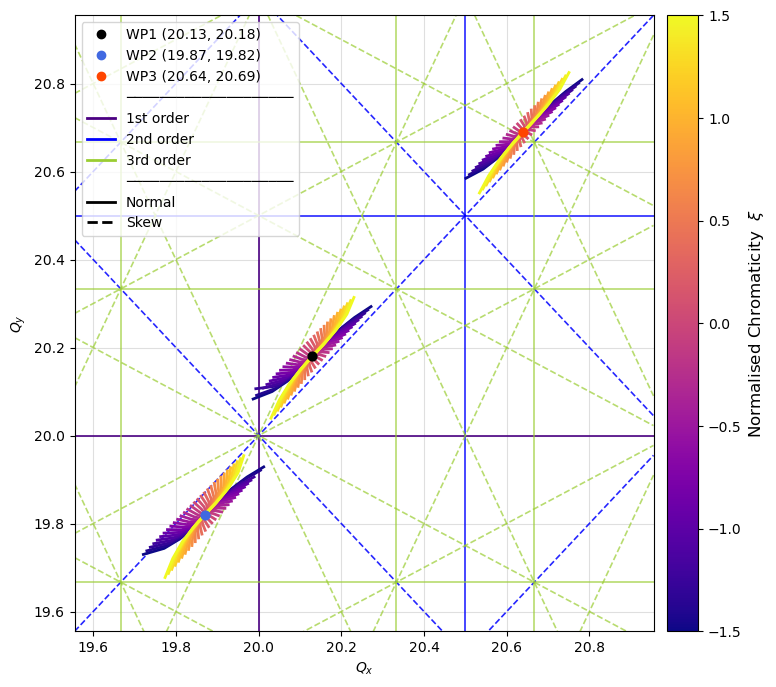

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))

td = TuneDiagram(qx0=20.255, qy0=20.255, half_range=0.7, max_order=3, skew=True)
td.plot(ax=ax, show_working_point=False) #working point will be plotted separately to be able to show both on the same plot

extra_handles = []
ax.scatter(20.13, 20.18, color="k",         zorder=5, s=40)
ax.scatter(19.87, 19.82, color="royalblue", zorder=5, s=40)
ax.scatter(20.64, 20.69, color="orangered", zorder=5, s=40)
extra_handles.append(lines.Line2D([], [], color="k",         marker="o", ls="None", markersize=6, label="WP1 (20.13, 20.18)"))
extra_handles.append(lines.Line2D([], [], color="royalblue", marker="o", ls="None", markersize=6, label="WP2 (19.87, 19.82)"))
extra_handles.append(lines.Line2D([], [], color="orangered", marker="o", ls="None", markersize=6, label="WP3 (20.64, 20.69)"))


qxs = [19.87, 20.13, 20.64]
qys = [19.82, 20.18, 20.69]
xi = np.round(np.linspace(-1.5, 1.5, 31), 1)
cmap = colormaps['plasma']
norm = plt.Normalize(vmin=xi[0], vmax=xi[-1])
sweep_trajectories = {}
for qx, qy in zip(qxs, qys):
    sweep_trajectories[(qx, qy)] = []
    for x in xi:
        env.vars['qph_setvalue'] = x
        env.vars['qpv_setvalue'] = x
        opt = line.match(
            method='6d', # <- passed to twiss
            vary=[
                xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
                xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
            ],
            targets = [
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
                xt.TargetSet(dqx=x*qx, dqy=x*qy, tol=1e-2, tag='chrom'),
            ])
        sweep_trajectories[(qx, qy)].append(SweepTrajectory.from_twiss_scan(line=line, delta_range=(-4e-3, 4e-3), step=1e-3))
        sweep_trajectories[(qx, qy)][-1].plot(ax, color=cmap(norm(x)))

# s1 = SweepTrajectory.from_twiss_scan(line=line, delta_range=(-4e-3, 4e-3), step=1e-4)
# s2 = SweepTrajectory.from_twiss_scan(line=line2, delta_range=(-4e-3, 4e-3), step=1e-4)

# h_wp1 = mlines.Line2D([], [], color="k",         marker="o", ls="None", markersize=6, label="WP1 (20.13, 20.18)")
# h_wp2 = mlines.Line2D([], [], color="royalblue", marker="o", ls="None", markersize=6, label="WP2 (19.87, 19.82)")
# h_s1  = s1.plot(ax, color="orangered",  label="Sweep WP1")
# h_s2  = s2.plot(ax, color="dodgerblue", label="Sweep WP2")

# td.finalize(ax, extra_handles=[h_wp1, h_wp2, h_s1, h_s2], xlabel=r"$Q_x$", ylabel=r"$Q_y$")
td.finalize(ax, extra_handles=extra_handles, xlabel=r"$Q_x$", ylabel=r"$Q_y$")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required by older mpl for colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Normalised Chromaticity  $\xi$", fontsize=12)
plt.savefig('Figures/TuneDiagrams/Errors/tune_diagram_WPAs_with_sweeps_restr.pdf', dpi=300)

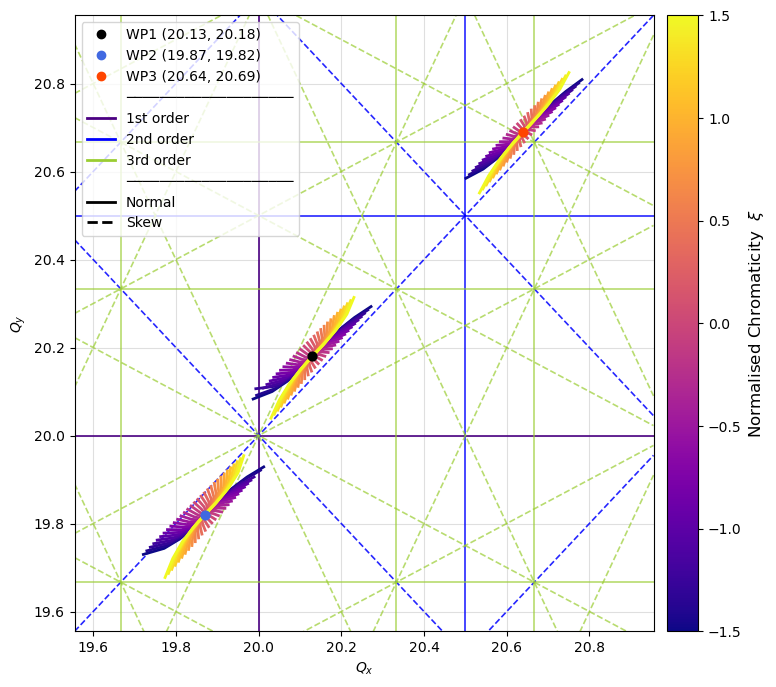

In [71]:
fig

## Sweep trajectories for qpx_zero

                                             
Optimize - start penalty: 29.19                             
Matching: model call n. 13 penalty = 9.7321e-04              
Optimize - end penalty:  0.000973213                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:427: UserWarning: twiss4d failed at δ=0.006: One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 1.00487038, 0.99515322, 1.        ,
       1.        ])
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 28.84                             
Matching: model call n. 13 penalty = 9.8066e-06              
Optimize - end penalty:  9.80659e-06                            
                                             
Optimize - start penalty: 26.83                             
Matching: model call n. 13 penalty = 1.0199e-05              
Optimize - end penalty:  1.01985e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:427: UserWarning: twiss4d failed at δ=0.005: 
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 24.83                             
Matching: model call n. 13 penalty = 9.5508e-06              
Optimize - end penalty:  9.55083e-06                            
                                             
Optimize - start penalty: 22.83                             
Matching: model call n. 7 penalty = 7.1736e-03              
Optimize - end penalty:  0.00717361                            
                                             
Optimize - start penalty: 20.83                             
Matching: model call n. 13 penalty = 4.7334e-06              
Optimize - end penalty:  4.73341e-06                            


...

                                             
Optimize - start penalty: 13.22                             
Matching: model call n. 7 penalty = 2.5252e-03              
Optimize - end penalty:  0.00252522                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:414: UserWarning: twiss4d failed at δ=-0.01: One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 0.99402135, 1.00601461])
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 15.22                             
Matching: model call n. 7 penalty = 1.5006e-03              
Optimize - end penalty:  0.00150061                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:414: UserWarning: twiss4d failed at δ=-0.009: Invalid n2
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 17.22                             
Matching: model call n. 13 penalty = 5.8571e-06              
Optimize - end penalty:  5.85714e-06                            
                                             
Optimize - start penalty: 19.22                             
Matching: model call n. 7 penalty = 7.2484e-03              
Optimize - end penalty:  0.00724841                            
                                             
Optimize - start penalty: 21.23                             
Matching: model call n. 13 penalty = 1.0765e-05              
Optimize - end penalty:  1.07648e-05                            
                                             
Optimize - start penalty: 23.23                             
Matching: model call n. 13 penalty = 4.7119e-05              
Optimize - end penalty:  4.7119e-05                            
                                             
Optimize - start pena

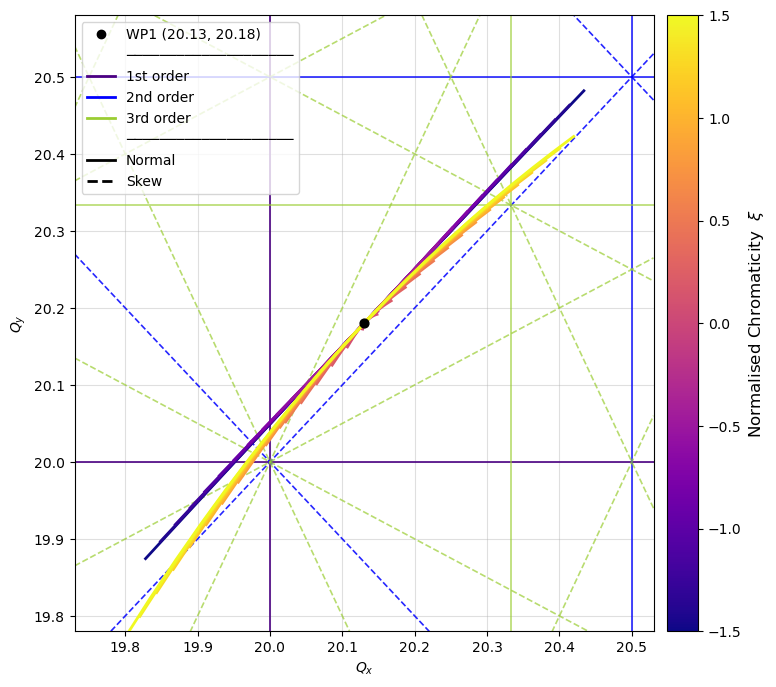

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))

td = TuneDiagram(qx0=20.13, qy0=20.18, half_range=0.4, max_order=3, skew=True)
td.plot(ax=ax, show_working_point=False) #working point will be plotted separately to be able to show both on the same plot

extra_handles = []
ax.scatter(20.13, 20.18, color="k",         zorder=5, s=40)
extra_handles.append(lines.Line2D([], [], color="k",         marker="o", ls="None", markersize=6, label="WP1 (20.13, 20.18)"))

# qxs = [19.87, 20.13, 20.64]
# qys = [19.82, 20.18, 20.69]
qxs = [20.13]
qys = [20.18]
xi = np.round(np.linspace(-1.5, 1.5, 31), 1)
cmap = colormaps['plasma']
norm = plt.Normalize(vmin=xi[0], vmax=xi[-1])
sweep_trajectories = {}
for qx, qy in zip(qxs, qys):
    sweep_trajectories[(qx, qy)] = []
    for x in xi:
        env.vars['qph_setvalue'] = 0
        env.vars['qpv_setvalue'] = x
        opt = line.match(
            method='6d', # <- passed to twiss
            vary=[
                xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
                xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
            ],
            targets = [
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
                xt.TargetSet(dqx=x*qx, dqy=x*qy, tol=1e-2, tag='chrom'),
            ])
        sweep_trajectories[(qx, qy)].append(SweepTrajectory.from_twiss_scan(line=line, delta_range=(-1e-2, 1e-2), step=1e-3))
        sweep_trajectories[(qx, qy)][-1].plot(ax, color=cmap(norm(x)))

td.finalize(ax, extra_handles=extra_handles, xlabel=r"$Q_x$", ylabel=r"$Q_y$")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required by older mpl for colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Normalised Chromaticity  $\xi$", fontsize=12)
plt.savefig('Figures/TuneDiagrams/NoErrors/tune_diagram_qpx_zero.pdf', dpi=300)

## Sweep trajectories for qpy_zero

                                             
Optimize - start penalty: 30.56                             
Matching: model call n. 13 penalty = 3.8793e-07              
Optimize - end penalty:  3.87934e-07                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:427: UserWarning: twiss4d failed at δ=0.006: One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 1.0048709 , 0.99515272, 1.        ,
       1.        ])
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 28.53                             
Matching: model call n. 7 penalty = 7.6156e-04              
Optimize - end penalty:  0.000761559                            
                                             
Optimize - start penalty: 26.51                             
Matching: model call n. 13 penalty = 2.0746e-05              
Optimize - end penalty:  2.07458e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:427: UserWarning: twiss4d failed at δ=0.005: 
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 24.48                             
Matching: model call n. 13 penalty = 5.5468e-05              
Optimize - end penalty:  5.54682e-05                            
                                             
Optimize - start penalty: 22.45                             
Matching: model call n. 13 penalty = 3.0101e-05              
Optimize - end penalty:  3.01015e-05                            
                                             
Optimize - start penalty: 20.42                             
Matching: model call n. 13 penalty = 1.0969e-05              
Optimize - end penalty:  1.09689e-05                            


...

                                             
Optimize - start penalty: 14.12                             
Matching: model call n. 7 penalty = 7.3110e-03              
Optimize - end penalty:  0.00731101                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:414: UserWarning: twiss4d failed at δ=-0.01: Invalid n2
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 16.15                             
Matching: model call n. 13 penalty = 1.2600e-05              
Optimize - end penalty:  1.25997e-05                            


/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions/tune_diagram.py:414: UserWarning: twiss4d failed at δ=-0.009: Invalid n2
  warnings.warn(f"twiss4d failed at δ={d:.6g}: {exc}")


                                             
Optimize - start penalty: 18.17                             
Matching: model call n. 7 penalty = 4.5499e-03              
Optimize - end penalty:  0.00454987                            
                                             
Optimize - start penalty: 20.2                              
Matching: model call n. 7 penalty = 8.6042e-03              
Optimize - end penalty:  0.00860422                            
                                             
Optimize - start penalty: 22.23                             
Matching: model call n. 13 penalty = 9.7378e-06              
Optimize - end penalty:  9.7378e-06                            
                                             
Optimize - start penalty: 24.26                             
Matching: model call n. 13 penalty = 6.1293e-06              
Optimize - end penalty:  6.12931e-06                            
                                             
Optimize - start penalt

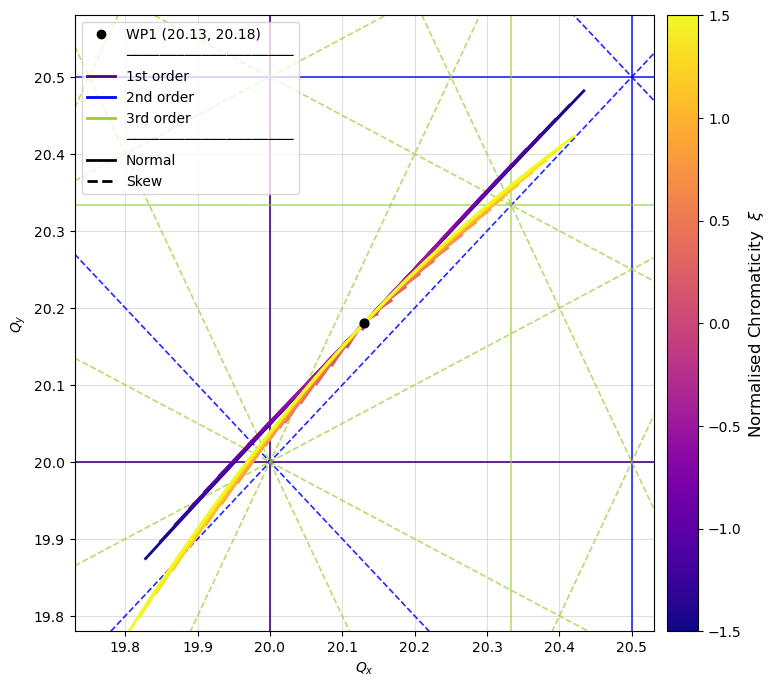

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))

td = TuneDiagram(qx0=20.13, qy0=20.18, half_range=0.4, max_order=3, skew=True)
td.plot(ax=ax, show_working_point=False) #working point will be plotted separately to be able to show both on the same plot

extra_handles = []
ax.scatter(20.13, 20.18, color="k",         zorder=5, s=40)
extra_handles.append(lines.Line2D([], [], color="k",         marker="o", ls="None", markersize=6, label="WP1 (20.13, 20.18)"))

# qxs = [19.87, 20.13, 20.64]
# qys = [19.82, 20.18, 20.69]
qxs = [20.13]
qys = [20.18]
xi = np.round(np.linspace(-1.5, 1.5, 31), 1)
cmap = colormaps['plasma']
norm = plt.Normalize(vmin=xi[0], vmax=xi[-1])
sweep_trajectories = {}
for qx, qy in zip(qxs, qys):
    sweep_trajectories[(qx, qy)] = []
    for x in xi:
        env.vars['qph_setvalue'] = x
        env.vars['qpv_setvalue'] = 0
        opt = line.match(
            method='6d', # <- passed to twiss
            vary=[
                xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
                xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
            ],
            targets = [
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
                xt.TargetSet(dqx=x*qx, dqy=x*qy, tol=1e-2, tag='chrom'),
            ])
        sweep_trajectories[(qx, qy)].append(SweepTrajectory.from_twiss_scan(line=line, delta_range=(-1e-2, 1e-2), step=1e-3))
        sweep_trajectories[(qx, qy)][-1].plot(ax, color=cmap(norm(x)))

td.finalize(ax, extra_handles=extra_handles, xlabel=r"$Q_x$", ylabel=r"$Q_y$")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required by older mpl for colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Normalised Chromaticity  $\xi$", fontsize=12)
plt.savefig('Figures/TuneDiagrams/NoErrors/tune_diagram_qpy_zero.pdf', dpi=300)